# Cleanliness
    - Author: Santiago Avella. Git hub: https://github.com/TiagoMimi

# Libraries

In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.ticker as ticker

pd.set_option("display.max_columns", None)

# Load data

In [49]:
script_path = Path.cwd() #Get the path of this scripts
csv_path = script_path.parent/"data"/"mall_medellin_recipts.csv" # Use the script's path as the reference to locate the CSV file.

df = pd.read_csv(csv_path,
                sep=";")

# Quality

In [50]:
df

,Unnamed: 0,year,quarter,customer_id,year_month,transaction_date,transaction_type,purchase_amount,store,business_establishment,gender,age_group,category,subcategory,day_week
0,0,2022,1Q,be189a4c9202d,2022-1,2022-01-02 00:00:00,Compra,50000,5385,CINE COLOMBIA,Masculino,18_32,ENTERTAINMENT,NaN,7
1,1,2022,1Q,be189a4c9202d,2022-1,2022-01-02 00:00:00,Compra,100000,NaN,LOCAL_NO_IDENTIFICADO,Masculino,18_32,NaN,NaN,7
2,2,2022,1Q,5c2d817105231,2022-1,2022-01-02 00:00:00,Compra,100000,6,HATOVIEJO,Masculino,59_71,RESTAURANTS_AND_FAST_FOOD,RESTAURANTS,7
3,3,2022,1Q,5f655501e54d3,2022-1,2022-01-02 00:00:00,Compra,270267,11111,CARULLA,Masculino,59_71,SUPERMARKET_AND_PHARMACY,NaN,7
4,4,2022,1Q,5f655501e54d3,2022-1,2022-01-02 00:00:00,Compra,220485,144,CAFÉ LE GRIS,Masculino,59_71,RESTAURANTS_AND_FAST_FOOD,RESTAURANTS,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453391,453391,2024,2Q,eaf0f11aaf2d4,2024-6,30/06/2024,Compra,105532,11111,CARULLA,Femenino,46_58,SUPERMARKET_AND_PHARMACY,NaN,7
453392,453392,2024,2Q,eaf0f11aaf2d4,2024-6,30/06/2024,Compra,37649,145,PASTEUR,Femenino,46_58,SUPERMARKET_AND_PHARMACY,NaN,7
453393,453393,2024,2Q,eaf0f11aaf2d4,2024-6,30/06/2024,Compra,227350,2104,MEDIPIEL,Femenino,46_58,BEAUTY_AND_COSMETIC_CENTERS,NaN,7
453394,453394,2024,2Q,6485ae245e887,2024-6,30/06/2024,Compra,245700,1408,MEDIPIEL 2,Femenino,33_45,SUPERMARKET_AND_PHARMACY,NaN,7


- Drop the column called Unnamed:0 because is a index column

In [51]:
df = df.drop(columns="Unnamed: 0")

## General info about the df

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453396 entries, 0 to 453395
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   year                    453396 non-null  int64 
 1   quarter                 453396 non-null  object
 2   customer_id             453396 non-null  object
 3   year_month              453396 non-null  object
 4   transaction_date        453396 non-null  object
 5   transaction_type        453396 non-null  object
 6   purchase_amount         453396 non-null  int64 
 7   store                   437445 non-null  object
 8   business_establishment  453346 non-null  object
 9   gender                  386428 non-null  object
 10  age_group               453396 non-null  object
 11  category                450734 non-null  object
 12  subcategory             153966 non-null  object
 13  day_week                453396 non-null  int64 
dtypes: int64(3), object(11)
memory usage

- Because the database was created in Microsoft Excel and compiled by copying and pasting data year by year, it is highly likely that duplicate records exist. Therefore, we will remove these duplicate rows.
- The reasoning is that it is highly unlikely for the same person to purchase the exact same item on the same day, at the same location, more than once.

In [53]:
def remove_duplicates_summary(df):
    """
    Delete duplicates rows froma a dataframe and print a summary about it

    Parameters
    
    df: pandas.Dataframe
        The dataframe that needs to be cleaned of duplicates

    Returns:

    1. df: pandas.Dataframe without duplicates rows.
    2. Summary of: Number of duplicated rows deleted and percentage of the original data that was deleted.
    """
    original_rows= len(df)
    
    df = df.drop_duplicates()

    duplicates_removed = original_rows - len(df)
    percentage_removed = round((duplicates_removed/original_rows)*100,3)

    print(f"Number of duplicated rows removed: {duplicates_removed}")
    print(f"Percentage of the original dataset removed: {percentage_removed}%")

    return df

In [54]:
df = remove_duplicates_summary(df)

Number of duplicated rows removed: 891
Percentage of the original dataset removed: 0.197%


In [55]:
def dataframe_quality_summary(df):

    """
    Generate a data quality summary for each column in a DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame
        The DataFrame to analyze.

    Returns
    -------
    pandas.DataFrame
        A summary DataFrame containing data quality metrics for each column.
    """
    column_summary = []

    for col in df.columns:                                    
        total_rows = len(df)
        null_count = df[col].isna().sum()
        null_percentage = round((null_count / total_rows) * 100, 2)
        valid_count = total_rows - null_count
        valid_percentage = round((valid_count / total_rows) * 100, 2)
        data_type = df[col].dtype

        column_summary.append({
            "Column_Name": col,
            "Data_Type": data_type,
            "Valid_Records": valid_count,
            "Valid_Percentage": valid_percentage,
            "Missing_Records": null_count,
            "Missing_Percentage": null_percentage
        })

    quality_summary = pd.DataFrame(column_summary)

    return quality_summary

In [56]:
dataframe_quality_summary(df)

,Column_Name,Data_Type,Valid_Records,Valid_Percentage,Missing_Records,Missing_Percentage
0,year,int64,452505,100.00,0,0.00
1,quarter,object,452505,100.00,0,0.00
2,customer_id,object,452505,100.00,0,0.00
3,year_month,object,452505,100.00,0,0.00
4,transaction_date,object,452505,100.00,0,0.00
5,transaction_type,object,452505,100.00,0,0.00
6,purchase_amount,int64,452505,100.00,0,0.00
7,store,object,436558,96.48,15947,3.52
8,business_establishment,object,452455,99.99,50,0.01
9,gender,object,385748,85.25,66757,14.75


- In this case we need to keep focus on the column "subcategory" because has the less than 40% of his data valiable to use.

# Cleanliness

In [57]:
def calculate_count_percentage(df, column):
    """
    Calculate the frequency and percentage distribution of the values in a column,
    including missing (NaN) values.

    Parameters
    ----------
    df : pandas.DataFrame
        The input DataFrame.
    column : str
        The name of the column for which the frequency distribution
        will be calculated.

    Returns
    -------
    pandas.DataFrame
        A DataFrame containing:
        - The unique values in the selected column (including NaN).
        - The count (frequency) of each value.
        - The percentage of each value relative to the total number of observations, rounded to three decimal places.
    """

    values_count = df[column].value_counts(dropna=False)

    values_percentage = df[column].value_counts(
        normalize=True, dropna=False
    ) * 100

    dataframe_frec = pd.DataFrame({
        column: values_count.index,
        "N°": values_count.values,
        "Percentage": values_percentage.values.round(3)
    })

    return dataframe_frec

In [58]:
def column_statistics(df, column):
    """
    Calculate descriptive statistics for a numerical column.

    Parameters
    ----------
    df : pandas.DataFrame
        The input DataFrame.
    column : str
        The name of the numerical column.

    Returns
    -------
    pandas.DataFrame
        A DataFrame with two columns:
        - Metric: Name of the statistic.
        - Value: Calculated statistic.
    """

    mean = df[column].mean()
    median = df[column].median()
    std = df[column].std()
    variance = df[column].var()
    minimum = df[column].min()
    percentile_25 = df[column].quantile(0.25)
    percentile_75 = df[column].quantile(0.75)
    maximum = df[column].max()
    skewness = df[column].skew()
    kurtosis = df[column].kurt()

    coefficient_of_variation = std / mean

    statistics = pd.DataFrame({
        "Metric": [
            "Mean",
            "Median",
            "Standard deviation",
            "Variance",
            "Minimum",
            "25th percentile",
            "75th percentile",
            "Maximum",
            "Skewness",
            "Kurtosis",
            "Coefficient of variation"
        ],
        "Value": [
            mean,
            median,
            std,
            variance,
            minimum,
            percentile_25,
            percentile_75,
            maximum,
            skewness,
            kurtosis,
            coefficient_of_variation,
        ]
    })
    
    statistics["Value"] = statistics["Value"].map(lambda x: f"{x:.3f}")
    return statistics

In [59]:
def change_data_type(dataframe, columns, dtype):    
    for column in columns:
        try:
            dataframe[column] = dataframe[column].astype(dtype)
            print(f"Dtype applied in '{column}'")
        except Exception as e:
            print(f"Error in '{column}':{e}")
    return(dataframe.info())

### Year

In [60]:
change_data_type(df,
                ["year"],
                str)

Dtype applied in 'year'
<class 'pandas.core.frame.DataFrame'>
Index: 452505 entries, 0 to 453395
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   year                    452505 non-null  object
 1   quarter                 452505 non-null  object
 2   customer_id             452505 non-null  object
 3   year_month              452505 non-null  object
 4   transaction_date        452505 non-null  object
 5   transaction_type        452505 non-null  object
 6   purchase_amount         452505 non-null  int64 
 7   store                   436558 non-null  object
 8   business_establishment  452455 non-null  object
 9   gender                  385748 non-null  object
 10  age_group               452505 non-null  object
 11  category                449847 non-null  object
 12  subcategory             153669 non-null  object
 13  day_week                452505 non-null  int64 
dtypes: int64(2), obje

In [61]:
calculate_count_percentage(df,"year")

,year,N°,Percentage
0,2022,201246,44.474
1,2023,172238,38.063
2,2024,79021,17.463


### Quarter

In [62]:
calculate_count_percentage(df,"quarter")

,quarter,N°,Percentage
0,1Q,133113,29.417
1,4Q,123599,27.314
2,2Q,117257,25.913
3,3Q,78536,17.356


### Customer_id

In [63]:
df["customer_id"].nunique()

52121

### year_month

In [64]:
calculate_count_percentage(df,"year_month")

,year_month,N°,Percentage
0,2022-12,33195,7.336
1,2023-12,26647,5.889
2,2023-1,22973,5.077
3,2022-11,19948,4.408
4,2023-2,18520,4.093
5,2022-6,18247,4.032
6,2022-7,17739,3.920
7,2022-10,16632,3.676
8,2024-1,16548,3.657
9,2023-11,15763,3.483


In [65]:
df["month"] = df["year_month"].str.split("-").str[1].astype(str)
df = df.drop(columns="year_month")

In [66]:
df

,year,quarter,customer_id,transaction_date,transaction_type,purchase_amount,store,business_establishment,gender,age_group,category,subcategory,day_week,month
0,2022,1Q,be189a4c9202d,2022-01-02 00:00:00,Compra,50000,5385,CINE COLOMBIA,Masculino,18_32,ENTERTAINMENT,NaN,7,1
1,2022,1Q,be189a4c9202d,2022-01-02 00:00:00,Compra,100000,NaN,LOCAL_NO_IDENTIFICADO,Masculino,18_32,NaN,NaN,7,1
2,2022,1Q,5c2d817105231,2022-01-02 00:00:00,Compra,100000,6,HATOVIEJO,Masculino,59_71,RESTAURANTS_AND_FAST_FOOD,RESTAURANTS,7,1
3,2022,1Q,5f655501e54d3,2022-01-02 00:00:00,Compra,270267,11111,CARULLA,Masculino,59_71,SUPERMARKET_AND_PHARMACY,NaN,7,1
4,2022,1Q,5f655501e54d3,2022-01-02 00:00:00,Compra,220485,144,CAFÉ LE GRIS,Masculino,59_71,RESTAURANTS_AND_FAST_FOOD,RESTAURANTS,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453391,2024,2Q,eaf0f11aaf2d4,30/06/2024,Compra,105532,11111,CARULLA,Femenino,46_58,SUPERMARKET_AND_PHARMACY,NaN,7,6
453392,2024,2Q,eaf0f11aaf2d4,30/06/2024,Compra,37649,145,PASTEUR,Femenino,46_58,SUPERMARKET_AND_PHARMACY,NaN,7,6
453393,2024,2Q,eaf0f11aaf2d4,30/06/2024,Compra,227350,2104,MEDIPIEL,Femenino,46_58,BEAUTY_AND_COSMETIC_CENTERS,NaN,7,6
453394,2024,2Q,6485ae245e887,30/06/2024,Compra,245700,1408,MEDIPIEL 2,Femenino,33_45,SUPERMARKET_AND_PHARMACY,NaN,7,6


In [67]:
calculate_count_percentage(df,"month")

,month,N°,Percentage
0,12,59842,13.225
1,1,52880,11.686
2,6,42921,9.485
3,2,42385,9.367
4,5,40478,8.945
5,3,37848,8.364
6,11,35711,7.892
7,4,33858,7.482
8,7,28394,6.275
9,10,28046,6.198


### transaction_date	

In [68]:
df = df.drop(columns="transaction_date")

- This column will be removed bcause we have already day of the week, month and year in this dataset. 

### transaction_type

In [69]:
calculate_count_percentage(df,"transaction_type")

,transaction_type,N°,Percentage
0,Compra,452505,100.0


- This column will be removed because every row has the same value.

In [70]:
df = df.drop(columns="transaction_type")

### purchase_amount

In [71]:
column_statistics(df,"purchase_amount")

,Metric,Value
0,Mean,295209.853
1,Median,104925.000
2,Standard deviation,3317649.027
3,Variance,11006795064214.107
4,Minimum,2000.000
5,25th percentile,49900.000
6,75th percentile,222124.000
7,Maximum,1199520000.000
8,Skewness,271.777
9,Kurtosis,91937.143


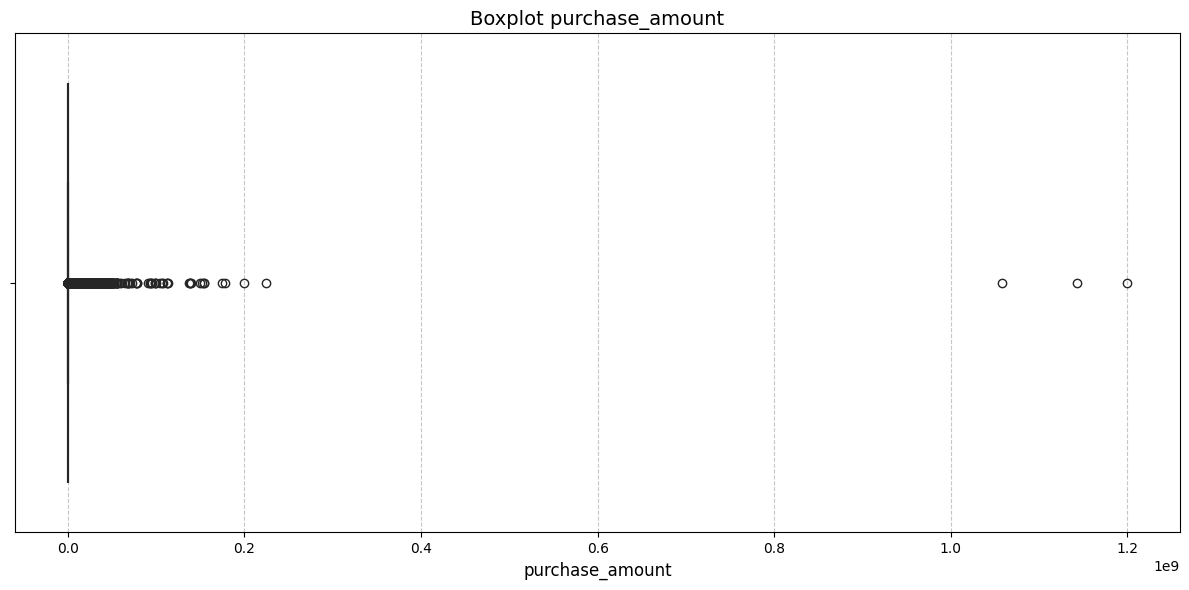

In [72]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x=df["purchase_amount"],
    color='teal',
    linewidth=1.5
)
plt.title("Boxplot purchase_amount", fontsize=14)
plt.xlabel("purchase_amount", fontsize=12)
plt.grid(axis='x',
        linestyle='--',
        alpha=0.7)
plt.tight_layout()
plt.show()

- The observed pattern in the graph is driven by three outliers. These observations will be removed during the data cleaning and preprocessing phase to improve the stability of the sample and reduce their influence on the analysis.

In [73]:
df = df[df["purchase_amount"] <= df["purchase_amount"].quantile(0.98)]

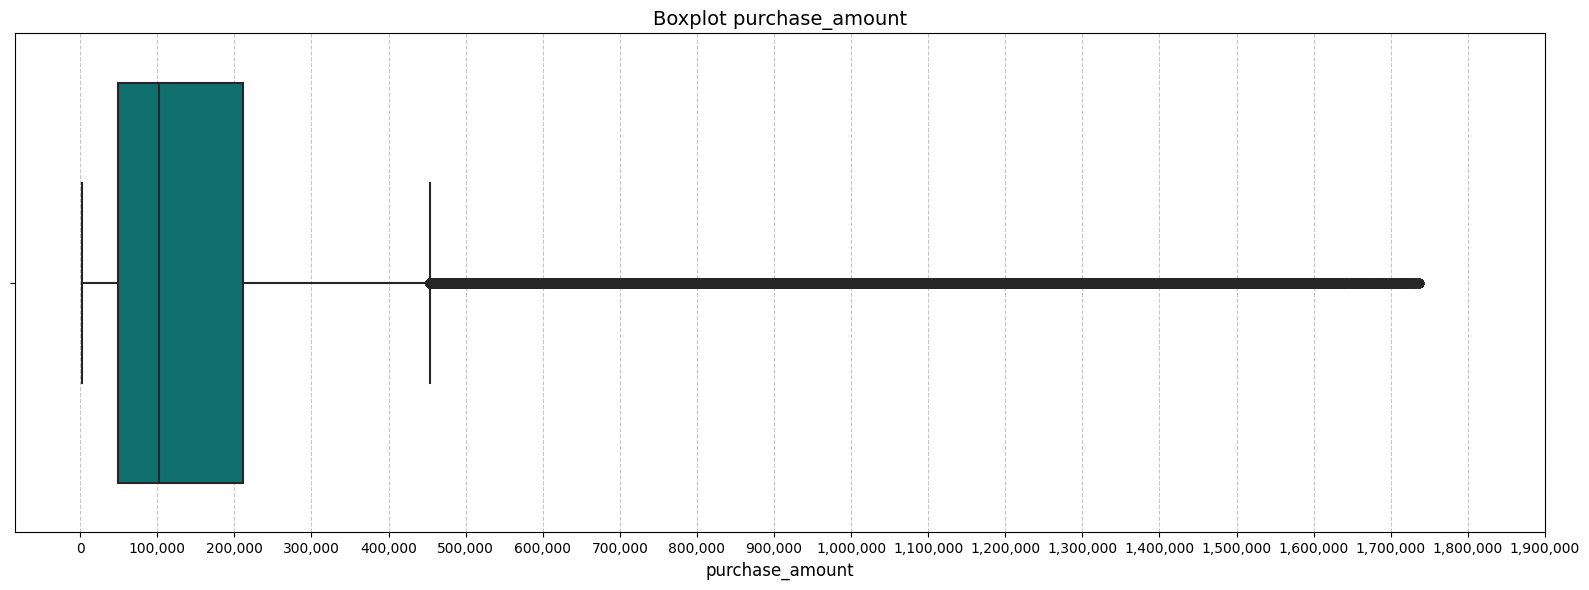

In [74]:
plt.figure(figsize=(16, 6))
sns.boxplot(
    x=df["purchase_amount"],
    color='teal',
    linewidth=1.5
)
plt.title("Boxplot purchase_amount", fontsize=14)
plt.xlabel("purchase_amount", fontsize=12)
plt.grid(axis='x',
        linestyle='--',
        alpha=0.7)
plt.gca().xaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)
plt.xticks(np.arange(0,2000000,100000))
plt.tight_layout()
plt.show()

- We removed the top 2% of the largest values because they were outliers and were skewing all measures of central tendency. Although a long tail of outliers is still present, we maintain the consistency of 98% of the total data.

### store

In [75]:
calculate_count_percentage(df,"store").head(20)

,store,N°,Percentage
0,11111,43965,9.914
1,2385,22128,4.990
2,5246,19210,4.332
3,NaN,15570,3.511
4,144,11250,2.537
5,3309,9400,2.120
6,3233,9396,2.119
7,1375,9020,2.034
8,3337,7461,1.682
9,2390,6943,1.566


In [76]:
df["store"].nunique()

294

- We have 294 unique store records. Stores are different from Business_stablishment, first are the physical location where the busisness stablisment buy or rent to put their busisness there, the second one is the brand. Yes, for a Mall, it could be usefull to know which physical location has better sales than others, but people are more likely to remember the brand than the specific store location, they only use this as a guide or landmark to move around the Mall. Therefore, we are going to delete this column.

In [77]:
df = df.drop(columns="store")

### business_establishment	

- As mentioned earlier, the original dataset is in Spanish (Colombia's official language). Therefore, some business names contain characters, called tildes(littel lines over the vowel) and spaces, which can causse issues when working with the data. To standardize the columns names, we will replace spaces with underscore (_) and remove the tildes.

In [78]:
df["business_establishment"] = (df["business_establishment"].str.lower()
                                                            .str.replace(" ","_")   
                                                            .str.encode("ascii", errors="ignore")
                                                            .str.decode("utf-8"))

In [79]:
calculate_count_percentage(df,"business_establishment").head(20)

,business_establishment,N°,Percentage
0,carulla,45257,10.206
1,crepes_&_waffles,22853,5.153
2,dollar_city,19811,4.467
3,bon-bonite,19380,4.370
4,caf_le_gris,11548,2.604
5,miniso,10762,2.427
6,esprit,7711,1.739
7,parmessano,7174,1.618
8,frisby,6579,1.484
9,cruz_verde,6579,1.484


### gender

In [80]:
df["gender"] = df["gender"].replace({"Femenino":"F",
                                    "Masculino" : "M"})
df["gender"] = df["gender"].fillna("unknown")

In [81]:
calculate_count_percentage(df,"gender")

,gender,N°,Percentage
0,F,291120,65.648
1,M,87009,19.621
2,unknown,65325,14.731


- This is important insight: On average, men earn higher incomes than womens in Colombia(and in the whole world too). If men generally have more money disposable to spend, why does the dataset contain more transactions made by women than by men?. That is a fact in this dataset even after combining the Male and Unkown gender categories, the number of rows with Women remains higher.

### age_group

- We are gonna to replace "edad_null" and "edad_error" to " age_unkown"

In [82]:
df["age_group"] = df["age_group"].replace({"edad_null" : "age_unknown",
                                        "edad_error" : "age_unknown",
                                        "72_mas" : "72_plus"})

In [83]:
calculate_count_percentage(df,"age_group")

,age_group,N°,Percentage
0,59_71,124692,28.118
1,46_58,108406,24.446
2,age_unknown,72824,16.422
3,33_45,71152,16.045
4,72_plus,49088,11.069
5,18_32,17292,3.899


- If we exclude the category age_unknown, two costumers groups stand out. People between 46 and 71 years old account the largest share. This insight has important strategic implications for the mall. Managment must decide which customer segment they want to prioritize: What kind of costumers do you want?. In one hand is to strengthen the mall's posisitiona mong its current costumers tailoring the shipping experience, brands, and services to middle-aged and older people. In the other hand the call could adopt a long-term growth strategy focused on attracting younger generations through new brands, entertraiment, events, etc. 

### category	

In [84]:
df["category"] = (df["category"].str.replace(r"\b_and_\b", " ", 
                                            regex=True))

In [85]:
df["category"] = (df["category"].str.lower()
                                .str.replace(" ","_")
                                .str.encode("ascii", errors="ignore")
                                .str.decode("utf-8"))

In [86]:
df["category"] = df["category"].fillna("Unknown")

In [87]:
calculate_count_percentage(df,"category")

,category,N°,Percentage
0,restaurants_and_fast_food,153644,34.647
1,clothing_and_fashion,77953,17.579
2,supermarket_and_pharmacy,74226,16.738
3,home_and_decor,37314,8.414
4,leather_and_footwear,30755,6.935
5,beauty_and_cosmetic_centers,20722,4.673
6,bookstores_stationery_and_copying,7585,1.710
7,miscellaneous_and_gifts,5100,1.150
8,jewelry_and_watches,5004,1.128
9,groceries_and_liquor,3858,0.870


### subcategory

In [88]:
df["subcategory"] = df["subcategory"].fillna("NO_FOOD")

In [89]:
calculate_count_percentage(df,"subcategory")

,subcategory,N°,Percentage
0,NO_FOOD,289815,65.354
1,RESTAURANTS,84857,19.135
2,FOOD_COURT,34518,7.784
3,COFFEE_SHOPS,32861,7.410
4,ICE_CREAM_SHOPS,1403,0.316


### day_week

- For Colombia people Sunday is ussually the first (1) day of the week (Religios background) but in this dataset is actually is Monday the First (1) day of the week.

In [90]:
df["day_week"] = df["day_week"].replace({1:"mon",
                                        2:"tue",
                                        3:"wed",
                                        4:"thu",
                                        5:"fri",
                                        6:"sat",
                                        7:"sun"})                                   

In [91]:
calculate_count_percentage(df,"day_week")

,day_week,N°,Percentage
0,sat,82508,18.606
1,sun,69263,15.619
2,fri,68348,15.413
3,wed,59030,13.311
4,thu,58325,13.152
5,tue,54766,12.350
6,mon,51214,11.549


## Write the csv

This gonna be the csv after the first cleanning process

In [92]:
df

,year,quarter,customer_id,purchase_amount,business_establishment,gender,age_group,category,subcategory,day_week,month
0,2022,1Q,be189a4c9202d,50000,cine_colombia,M,18_32,entertainment,NO_FOOD,sun,1
1,2022,1Q,be189a4c9202d,100000,local_no_identificado,M,18_32,Unknown,NO_FOOD,sun,1
2,2022,1Q,5c2d817105231,100000,hatoviejo,M,59_71,restaurants_and_fast_food,RESTAURANTS,sun,1
3,2022,1Q,5f655501e54d3,270267,carulla,M,59_71,supermarket_and_pharmacy,NO_FOOD,sun,1
4,2022,1Q,5f655501e54d3,220485,caf_le_gris,M,59_71,restaurants_and_fast_food,RESTAURANTS,sun,1
...,...,...,...,...,...,...,...,...,...,...,...
453391,2024,2Q,eaf0f11aaf2d4,105532,carulla,F,46_58,supermarket_and_pharmacy,NO_FOOD,sun,6
453392,2024,2Q,eaf0f11aaf2d4,37649,pasteur,F,46_58,supermarket_and_pharmacy,NO_FOOD,sun,6
453393,2024,2Q,eaf0f11aaf2d4,227350,medipiel,F,46_58,beauty_and_cosmetic_centers,NO_FOOD,sun,6
453394,2024,2Q,6485ae245e887,245700,medipiel_2,F,33_45,supermarket_and_pharmacy,NO_FOOD,sun,6


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 443454 entries, 0 to 453395
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   year                    443454 non-null  object
 1   quarter                 443454 non-null  object
 2   customer_id             443454 non-null  object
 3   purchase_amount         443454 non-null  int64 
 4   business_establishment  443404 non-null  object
 5   gender                  443454 non-null  object
 6   age_group               443454 non-null  object
 7   category                443454 non-null  object
 8   subcategory             443454 non-null  object
 9   day_week                443454 non-null  object
 10  month                   443454 non-null  object
dtypes: int64(1), object(10)
memory usage: 40.6+ MB


 ## Dataset Characteristics

- 443454 rows (no duplicates)
- 11 Columns (With no NaN):
    - 1 Numeric variables: Purchase amount 
    - 10 Categorical variables: Year, Quarter, Customer ID, Business_stablishment, Gender, Age Group, Category, Subcategory, Day_week, Month. 

In [94]:
csv_path_towrite = script_path.parent/"data"/"mall_medellin_v1.csv" 

df.to_csv(csv_path_towrite,
        index=False,
        sep=";")